
=== Risk Scores ===

Gateway : 1.0
LoadBalancer : 1.0
AppServerA : 0.518
AppServerB : 0.482
InternalSwitch : 1.0
Database : 1.0

Suggested IDS Placement Nodes:

Gateway Risk: 1.0
LoadBalancer Risk: 1.0


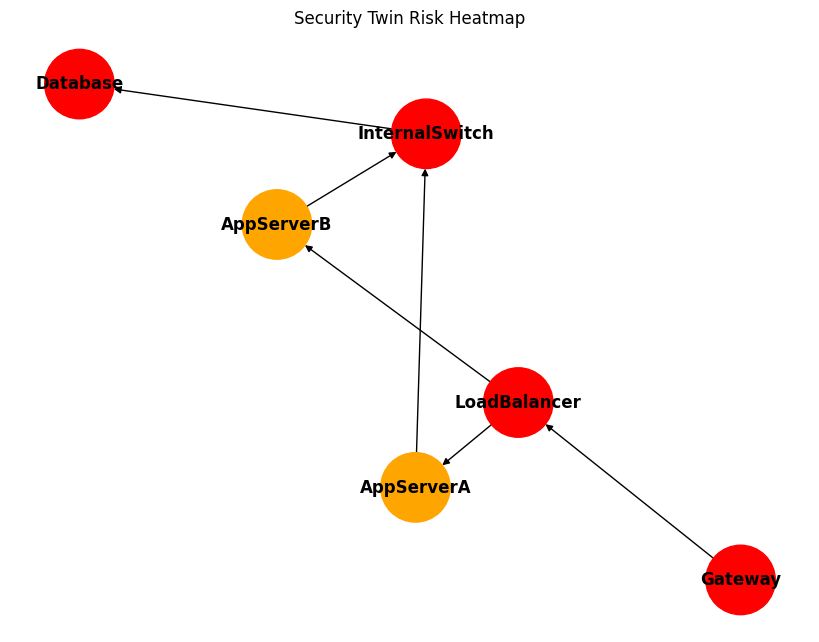

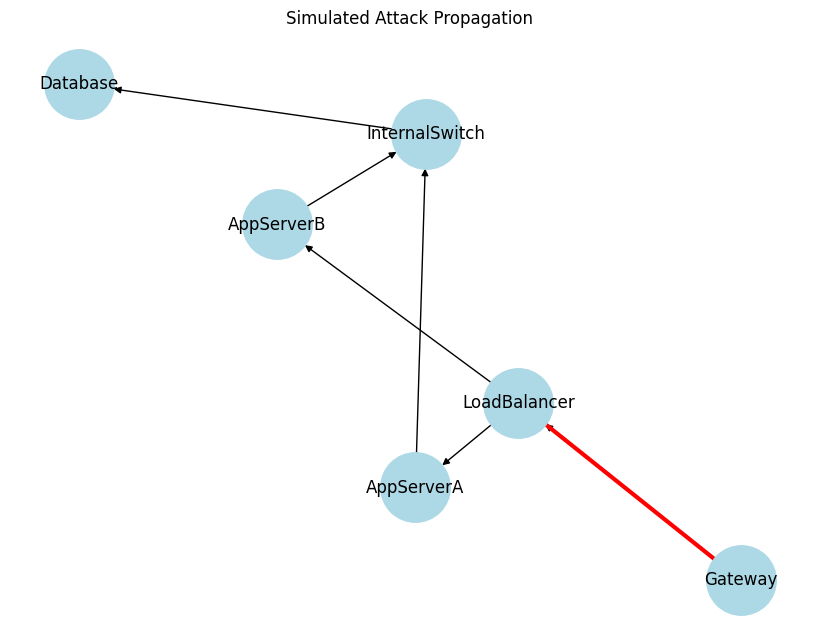

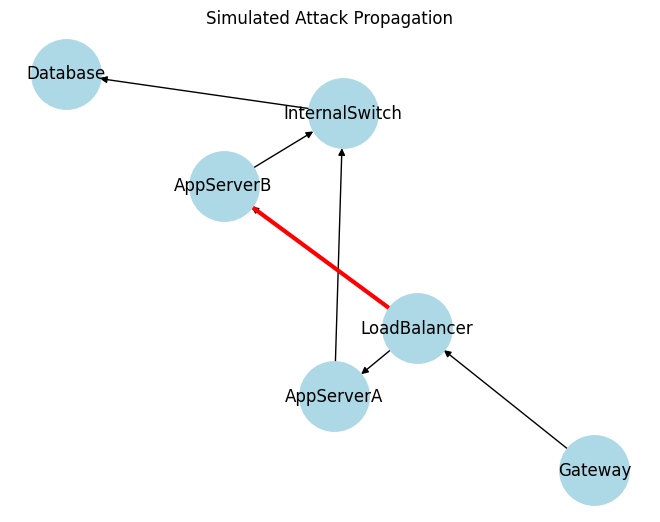

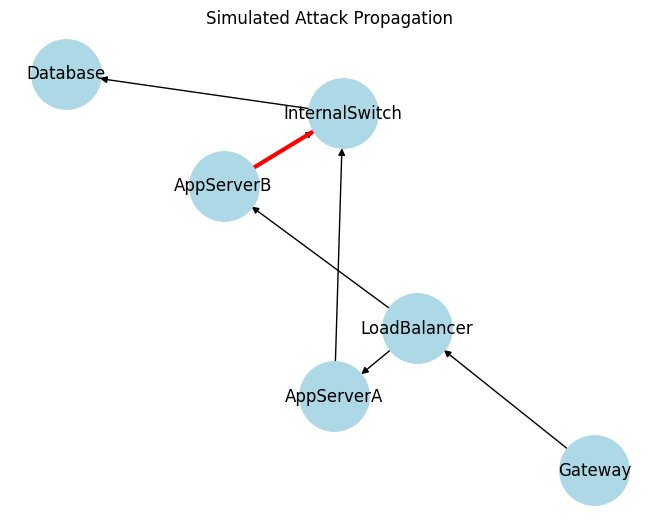

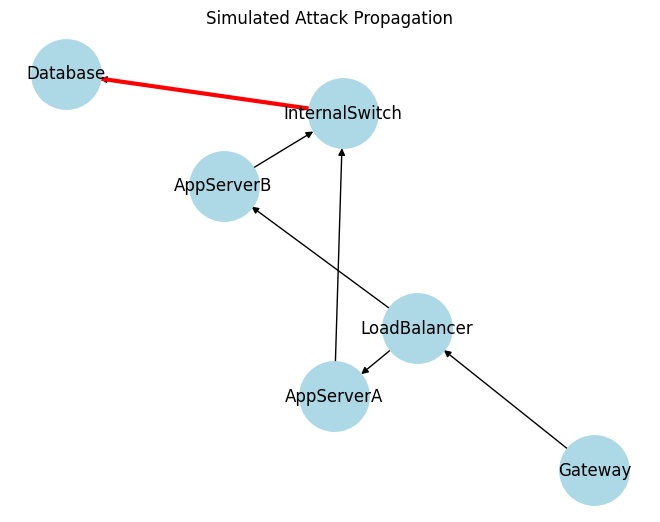

In [5]:

import networkx as nx
import matplotlib.pyplot as plt
import random
from collections import Counter
import time


G = nx.DiGraph()

nodes = [
    "Gateway",
    "LoadBalancer",
    "AppServerA",
    "AppServerB",
    "InternalSwitch",
    "Database"
]

edges = [
    ("Gateway","LoadBalancer"),
    ("LoadBalancer","AppServerA"),
    ("LoadBalancer","AppServerB"),
    ("AppServerA","InternalSwitch"),
    ("AppServerB","InternalSwitch"),
    ("InternalSwitch","Database")
]

G.add_nodes_from(nodes)
G.add_edges_from(edges)



attack_paths = [
    ["Gateway","LoadBalancer","AppServerA","InternalSwitch","Database"],
    ["Gateway","LoadBalancer","AppServerB","InternalSwitch","Database"]
]



NUM_ATTACKS = 1000
node_counter = Counter()

for _ in range(NUM_ATTACKS):

    path = random.choice(attack_paths)

    for node in path:
        node_counter[node] += 1



risk_scores = {}

for node in nodes:
    risk_scores[node] = node_counter[node] / NUM_ATTACKS

print("\n=== Risk Scores ===\n")

for node,score in risk_scores.items():
    print(node,":",round(score,3))



sorted_nodes = sorted(risk_scores.items(), key=lambda x: x[1], reverse=True)

print("\nSuggested IDS Placement Nodes:\n")

for node,score in sorted_nodes[:2]:
    print(node,"Risk:",round(score,3))


pos = nx.spring_layout(G, seed=42)

colors = []

for node in G.nodes():

    score = risk_scores[node]

    if score > 0.8:
        colors.append("red")

    elif score > 0.4:
        colors.append("orange")

    else:
        colors.append("lightblue")

plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color=colors,
    font_weight="bold"
)

plt.title("Security Twin Risk Heatmap")

plt.show()



plt.figure(figsize=(8,6))

path = random.choice(attack_paths)

for i in range(len(path)-1):

    nx.draw(G,pos,with_labels=True,node_size=2500,node_color="lightblue")

    edge = (path[i],path[i+1])

    nx.draw_networkx_edges(
        G,pos,
        edgelist=[edge],
        edge_color="red",
        width=3
    )

    plt.title("Simulated Attack Propagation")
    plt.pause(1)

plt.show()